## Option Data Download

In [1]:
# from data_loader.fetch_option_data import fetch_data_by_month
# fetch_data_by_month("MU", "2016-01-01", "2026-03-15")

## Bcaktesting the Wheel Strategy

In [2]:
from backtester.backtest import run_wheel_backtest
from backtester.report import WheelPerformanceReport

symbol = "SPY"

result = run_wheel_backtest(
    symbol=symbol,
    start_date="2016-01-01",
    end_date="2026-03-15",
    target_delta=0.2,
    stop_loss_multiple=1.5,
    put_exp_days=12,
    call_exp_days=0,
    initial_cash=7500,
    leverage=10,
)

report = WheelPerformanceReport(result)

In [3]:
report.summary_table()

,Value
Metric,
Symbol,SPY
Start Date,2016-01-04
End Date,2026-03-13
Initial Cash,"$7,500.00"
Ending Equity,"$26,070.21"
Net Profit,"$18,570.21"
Cash Interest Earned,"$3,553.71"
Total Return,247.60%
CAGR,13.01%


In [4]:
report.trade_breakdown_table()

,legs,total_premium,avg_premium,avg_roi,avg_iv,avg_abs_delta,avg_moneyness,avg_days_held
type,,,,,,,,
put,385,"$64,428.50",$167.35,0.12%,19.91%,0.20,-2.99%,8.31


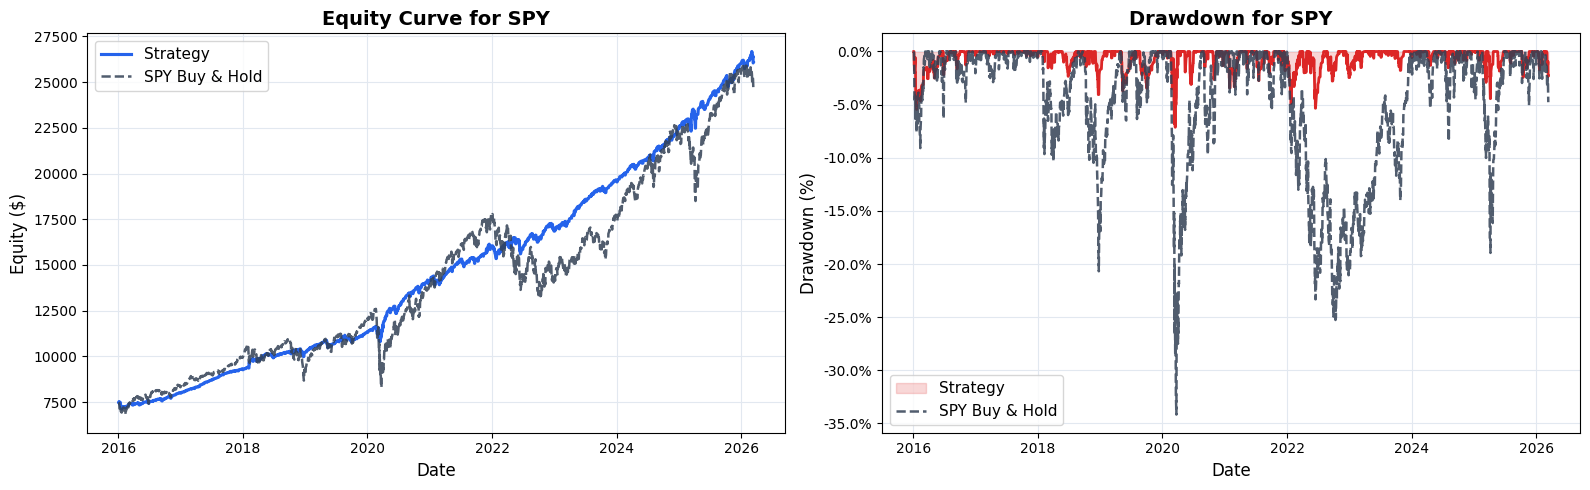

In [5]:
_ = report.plot_equity_and_drawdown()

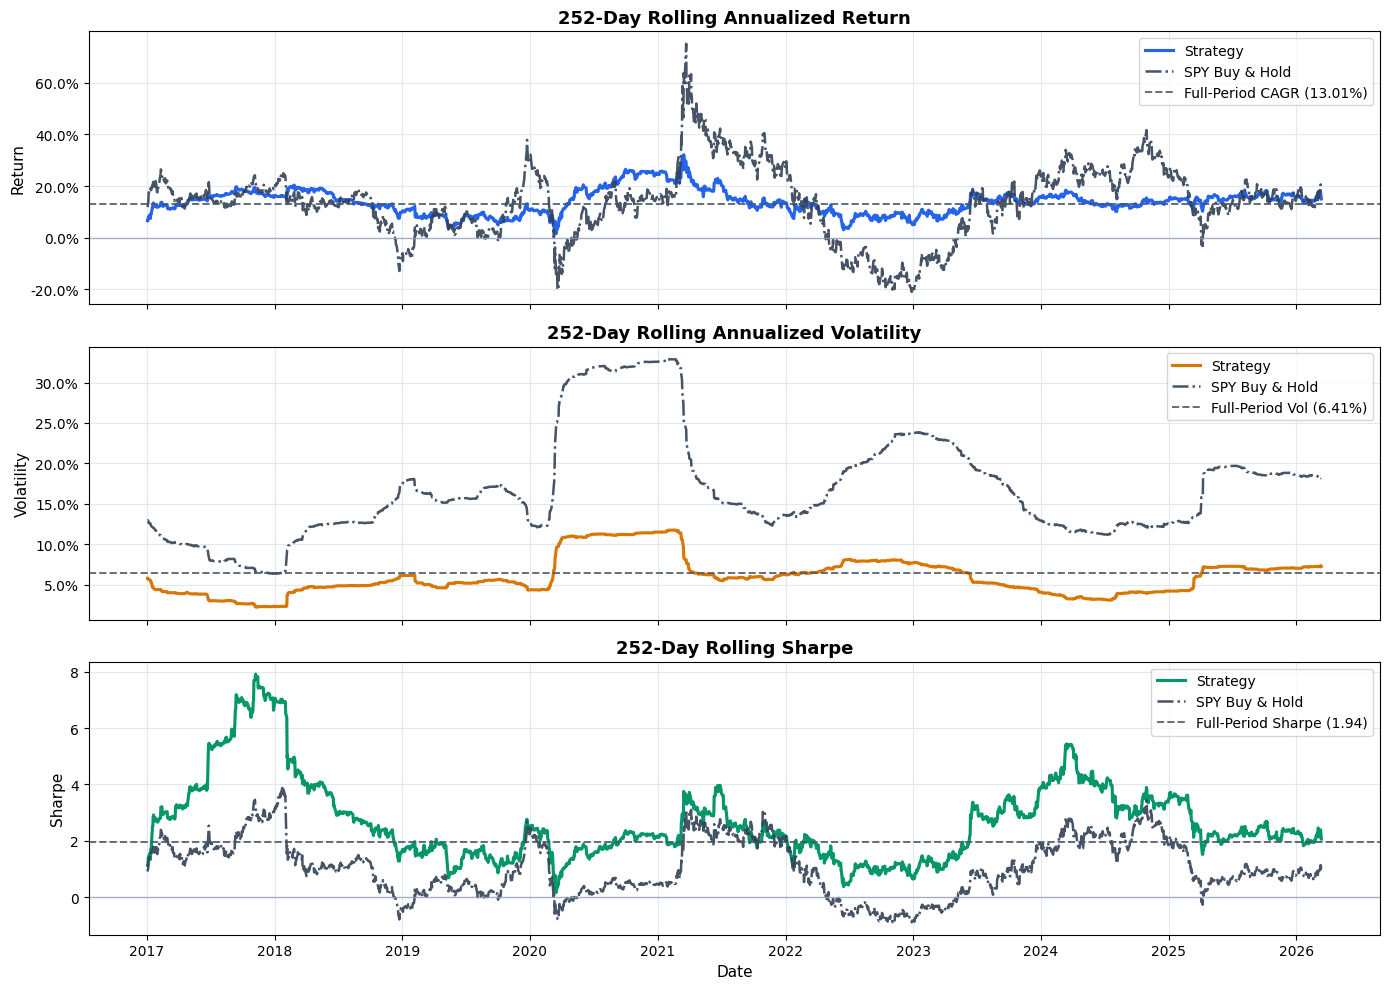

In [6]:
_ = report.plot_rolling_metrics(252)

,count,mean,sum,premium_collected,cut_loss
expiration_weekday,,,,,
Monday,167.0,39.651198,6621.75,31354.5,-24732.75
Tuesday,48.0,24.958333,1198.00,8501.0,-7303.00
Wednesday,145.0,47.798276,6930.75,21453.0,-14432.25
Thursday,1.0,-66.750000,-66.75,133.5,-200.25
Friday,24.0,13.864583,332.75,2986.5,-2653.75


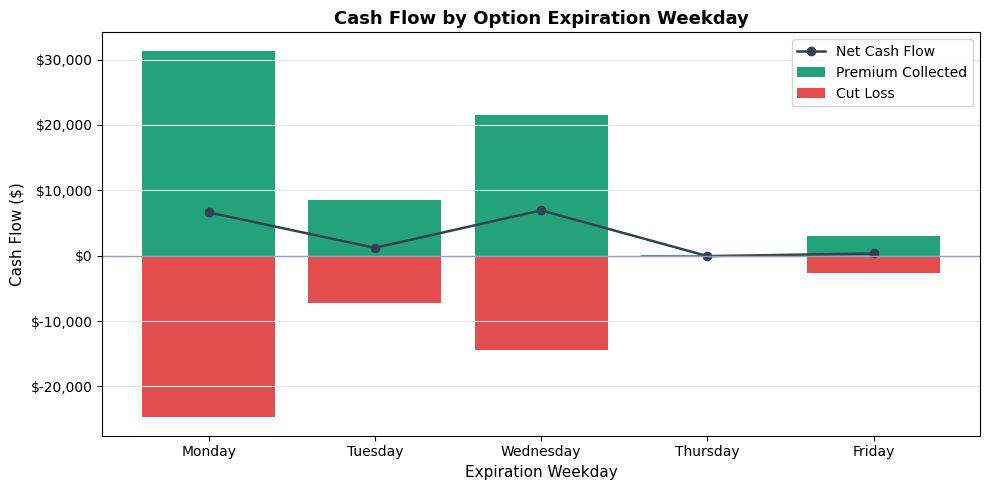

In [15]:
_, res = report.plot_cash_flow_by_expiration_weekday()
res

In [8]:
from IPython.display import HTML, display

def display_long_df(df, max_height=400, max_width='100%'):
    html = (
        f"<div style='max-height:{max_height}px; overflow:auto; width:{max_width}; padding:5px;'>"
        f"{df.to_html(escape=False, index=False)}"
        f"</div>"
    )
    display(HTML(html))

display_long_df(result.trades)

date,side,type,strike,expiration,premium_per_share,premium,delta,leverage_ratio,moneyness,iv,outcome,days_held,ROI%,cash_flow,nav,exec_spot,spot,buyback_price_per_share,stop_trigger_price_per_share,stop_open_price_per_share,liquidation_cost,expiration_weekday
2016-01-04,short,put,194.5,2016-01-22,1.285,128.5,-0.224716,2.593333,-3.426018,0.215812,cut_loss,2,-0.336761,-65.50,7434.605498,201.400,199.050,1.9400,2.10,1.94,NaN,Friday
2016-01-07,short,put,185.0,2016-01-22,1.115,111.5,-0.188225,2.488347,-4.540764,0.266795,cut_loss,6,-0.301351,-55.75,7379.119462,193.800,188.750,1.6725,1.71,0.36,NaN,Friday
2016-01-14,short,put,184.0,2016-01-29,1.190,119.0,-0.203552,2.493501,-4.141704,0.261087,cut_loss,1,-0.989130,-182.00,7197.242386,191.950,187.810,3.0100,3.76,3.01,NaN,Friday
2016-01-19,short,put,178.0,2016-02-05,1.390,139.0,-0.195778,2.473148,-5.288922,0.304752,cut_loss,1,-0.438202,-78.00,7119.369843,187.940,186.050,2.1700,3.59,2.17,NaN,Friday
2016-01-21,short,put,177.0,2016-02-05,1.350,135.0,-0.195678,2.486152,-5.154860,0.317877,expired,15,0.762712,135.00,7255.303343,186.620,188.150,NaN,NaN,NaN,NaN,Friday
2016-02-08,short,put,176.5,2016-02-26,1.285,128.5,-0.194357,2.432677,-5.030939,0.279949,cut_loss,3,-0.427762,-75.50,7180.103319,185.850,183.090,2.0400,2.50,2.04,NaN,Friday
2016-02-12,short,put,179.0,2016-02-26,1.140,114.0,-0.206171,2.492975,-3.969957,0.261892,expired,14,0.636872,114.00,7294.874740,186.400,194.900,NaN,NaN,NaN,NaN,Friday
2016-02-29,short,put,185.0,2016-03-18,1.215,121.5,-0.204496,2.535999,-4.466822,0.238883,expired,18,0.656757,121.50,7417.556711,193.650,204.310,NaN,NaN,NaN,NaN,Friday
2016-03-21,short,put,199.5,2016-04-08,0.725,72.5,-0.199201,2.689537,-2.568861,0.140980,cut_loss,3,-0.403509,-80.50,7337.361653,204.760,203.310,1.5300,1.53,1.53,NaN,Friday
2016-03-28,short,put,197.5,2016-04-15,0.815,81.5,-0.200648,2.691677,-2.833809,0.157963,expired,18,0.412658,81.50,7419.719223,203.260,207.960,NaN,NaN,NaN,NaN,Friday


## Grid Search for Hyperparameter Optimization

In [9]:
import pandas as pd
from backtester.grid_search import run_grid_search

# grid_results_spy = run_grid_search(
#     symbol=symbol,
#     start_date="2016-01-01",
#     end_date="2026-03-15",
#     initial_cash=8_000,
#     leverage=10,
#     max_workers=5,
# )

In [10]:
grid_results_spy = pd.read_csv("data/grid_search/grid_results_spy.csv")
filtered_results = grid_results_spy[grid_results_spy["cagr"] > 0.1]
display_long_df(filtered_results[["case", "cagr", "sharpe", "max_drawdown"]].sort_values(by=["sharpe", "cagr"], ascending=False))

case,cagr,sharpe,max_drawdown
"delta=0.2, stop=1.5, put_dte=12",0.125498,1.954676,-0.068227
"delta=0.2, stop=1.5, put_dte=10",0.113923,1.922210,-0.106944
"delta=0.1, stop=4.0, put_dte=12",0.109473,1.876094,-0.087241
"delta=0.15, stop=3.0, put_dte=12",0.113493,1.729175,-0.104185
"delta=0.25, stop=1.5, put_dte=12",0.133636,1.705612,-0.112991
"delta=0.25, stop=1.5, put_dte=10",0.115778,1.543641,-0.122455
"delta=0.15, stop=4.0, put_dte=12",0.115154,1.479655,-0.134218
"delta=0.2, stop=1.5, put_dte=20",0.113677,1.474485,-0.166712
"delta=0.2, stop=1.5, put_dte=14",0.111191,1.462553,-0.143152
"delta=0.2, stop=1.5, put_dte=30",0.105059,1.417694,-0.152660


In [11]:
# grid_results_qqq = run_grid_search(
#     symbol="QQQ",
#     start_date="2016-01-01",
#     end_date="2026-03-15",
#     initial_cash=5_000,
#     leverage=10,
#     max_workers=5,
# )

In [12]:
grid_results_qqq = pd.read_csv("data/grid_search/grid_results_qqq.csv")
filtered_results = grid_results_qqq[grid_results_qqq["cagr"] > 0.1]
display_long_df(filtered_results[["case", "cagr", "sharpe", "max_drawdown"]].sort_values(by=["sharpe", "cagr"], ascending=False))

case,cagr,sharpe,max_drawdown
"delta=0.1, stop=2.0, put_dte=3",0.108635,1.974154,-0.115251
"delta=0.1, stop=1.5, put_dte=12",0.107227,1.618100,-0.106616
"delta=0.2, stop=1.5, put_dte=10",0.140161,1.566346,-0.109646
"delta=0.1, stop=1.5, put_dte=14",0.102347,1.479719,-0.076001
"delta=0.1, stop=3.0, put_dte=3",0.105838,1.479695,-0.136096
"delta=0.1, stop=1.5, put_dte=10",0.102087,1.470498,-0.082580
"delta=0.15, stop=1, put_dte=10",0.112454,1.448498,-0.158845
"delta=0.15, stop=1.5, put_dte=3",0.114911,1.437033,-0.183761
"delta=0.15, stop=1.5, put_dte=12",0.120498,1.436735,-0.128770
"delta=0.15, stop=1.5, put_dte=10",0.115227,1.436246,-0.135147


In [13]:
from pathlib import Path

data_dir = Path("data/grid_search")
data_dir.mkdir(parents=True, exist_ok=True)

grid_results_spy.to_csv(data_dir / "grid_results_spy.csv", index=False)
grid_results_qqq.to_csv(data_dir / "grid_results_qqq.csv", index=False)